In [ ]:
import os, re, random, math
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications.resnet import preprocess_input
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

### 새로운 화재 데이터셋(fire_new)에 [석양 데이터셋](https://universe.roboflow.com/testspace-s4qzg/test_image_0227/dataset/1) 추가해서 모델 재학습

In [ ]:
# ----------------------------
# 1) SETTINGS
# ----------------------------
BASE = Path("/content/drive/MyDrive/2025-KT-AIVLESCHOOL/Big-Project")
WORK = BASE / "work"

FIRE_ROOT = WORK / "fire_new" / "fire_new"
CLEAN_MERGED = WORK / "clean_merged"
CKPT_DIR = WORK / "ckpt"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# 새 화재 데이터셋은 이미 train/val/test로 분리되어 있음
# - 구조 예시:
#   FIRE_ROOT/
#     train/fire, train/smoke, train/normal
#     val/fire,   val/smoke,   val/normal
#     test/fire,  test/smoke,  test/normal
#
# - normal을 other로 "클래스 이름만" 매핑해서 기존 코드 흐름(FIRE_CLASSES) 유지
FIRE_CLASSES = ["fire", "smoke", "other"]  # (유지) 모델 출력 순서 유지
FIRE_ALIAS = {"normal": "other"}           # (추가) normal -> other 매핑

CLEAN_CLASSES = ["clean", "dirty"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

BATCH_SIZE = 16
IMG_SIZE = 224
EPOCHS = 10
SEED = 2026

# (변경) 새 fire 데이터는 이미 split이 고정되어 있어 TEST_SIZE/VAL_SIZE_IN_TRAINVAL 사용 안 함(train: 0.8/val: 0.12/test: 0.08)
# TEST_SIZE = 0.15
# VAL_SIZE_IN_TRAINVAL = 0.15

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ----------------------------
# 2) DATA LISTING
# ----------------------------
def list_images(root: Path, class_names, alias_map=None):
    """
    (변경) alias_map을 지원:
      - 폴더명이 class_names와 다를 수 있을 때(예: normal) 매핑 처리
      - class_names 인덱스 순서는 그대로 유지됨 (fire=0, smoke=1, other=2)
    """
    items = []
    alias_map = alias_map or {}

    for i, cname in enumerate(class_names):
        # (추가) class_name -> 실제 폴더명 후보 생성
        # ex) cname="other" 이면 alias_map 역매핑으로 "normal"도 후보로 포함
        candidates = [cname]
        # alias_map: {"normal":"other"} 형태이므로, other의 실제 폴더명 후보는 normal
        for real_name, mapped in alias_map.items():
            if mapped == cname:
                candidates.append(real_name)

        found_any = False
        for folder_name in candidates:
            cdir = root / folder_name
            if not cdir.exists():
                continue
            found_any = True
            for p in cdir.rglob("*"):
                if p.is_file() and p.suffix.lower() in IMG_EXTS:
                    items.append((str(p), i))
        if not found_any:
            # 폴더가 아예 없으면 그냥 스킵
            pass

    return items

def extract_paths_labels(samples):
    return [s[0] for s in samples], [s[1] for s in samples]

# (변경) FIRE_ROOT: 위 "압축 해제 셀"에서 FIRE_ROOT를 만들어둔 것을 사용

# (추가) 새 화재 데이터셋의 split root 정의
FIRE_TRAIN_ROOT = FIRE_ROOT / "train"
FIRE_VAL_ROOT   = FIRE_ROOT / "valid"
FIRE_TEST_ROOT  = FIRE_ROOT / "test"

# (변경) fire는 split별로 별도 로딩 (더 이상 GroupShuffleSplit/StratifiedShuffleSplit로 나누지 않음)
fire_train = list_images(FIRE_TRAIN_ROOT, FIRE_CLASSES, alias_map=FIRE_ALIAS)
fire_val   = list_images(FIRE_VAL_ROOT,   FIRE_CLASSES, alias_map=FIRE_ALIAS)
fire_test  = list_images(FIRE_TEST_ROOT,  FIRE_CLASSES, alias_map=FIRE_ALIAS)

fire_p_tr, fire_y_tr = extract_paths_labels(fire_train)
fire_p_va, fire_y_va = extract_paths_labels(fire_val)
fire_p_test, fire_y_test = extract_paths_labels(fire_test)

# CLEAN은 기존처럼 전체를 로드 후 train/val/test split을 내부에서 만듦(기존 구조 유지)
cln_all  = list_images(CLEAN_MERGED, CLEAN_CLASSES)
cln_p_all,  cln_y_all  = extract_paths_labels(cln_all)

print("[TOTAL]")
print("FIRE train:", len(fire_p_tr), "| valid:", len(fire_p_va), "| test:", len(fire_p_test))
print("CLEAN total:", len(cln_p_all))

# ----------------------------
# 3) CLEAN SPLIT (keep existing behavior)
# ----------------------------
# (유지) clean은 기존처럼 fixed test + train/val 분리
TEST_SIZE = 0.15
VAL_SIZE_IN_TRAINVAL = 0.15

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
cln_idx = np.arange(len(cln_p_all))
cln_trainval_idx, cln_test_idx = next(sss.split(cln_idx, cln_y_all))

cln_p_test = [cln_p_all[i] for i in cln_test_idx]
cln_y_test = [cln_y_all[i] for i in cln_test_idx]

cln_p_trainval = [cln_p_all[i] for i in cln_trainval_idx]
cln_y_trainval = [cln_y_all[i] for i in cln_trainval_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE_IN_TRAINVAL, random_state=SEED)
c_idx2 = np.arange(len(cln_p_trainval))
c_tr_idx, c_va_idx = next(sss2.split(c_idx2, cln_y_trainval))

cln_p_tr = [cln_p_trainval[i] for i in c_tr_idx]
cln_y_tr = [cln_y_trainval[i] for i in c_tr_idx]
cln_p_va = [cln_p_trainval[i] for i in c_va_idx]
cln_y_va = [cln_y_trainval[i] for i in c_va_idx]

print("\n[CLEAN SPLIT]")
print("CLEAN train/valid/test:", len(cln_p_tr), len(cln_p_va), len(cln_p_test))

# ----------------------------
# 5) TF DATA PIPELINE (task별 헤드만 학습)
# ----------------------------
def parse_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)
    return img

fire_w_map  = tf.constant([1.0, 1.1, 1.2], dtype=tf.float32)
clean_w_map = tf.constant([0.9, 1.1], dtype=tf.float32)

def make_fire_ds(paths, labels, batch_size=BATCH_SIZE, is_train=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if is_train:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True).repeat()
    ds = ds.map(lambda p, y: (parse_img(p), tf.cast(y, tf.int32)),
                num_parallel_calls=tf.data.AUTOTUNE)

    def pack(img, y_fire):
        w_fire = tf.gather(fire_w_map, y_fire)
        y = {"fire_output": y_fire, "clean_output": tf.zeros_like(y_fire)}
        w = {"fire_output": w_fire, "clean_output": tf.zeros_like(w_fire)}
        return img, y, w

    ds = ds.map(pack, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def make_clean_ds(paths, labels, batch_size=BATCH_SIZE, is_train=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if is_train:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True).repeat()
    ds = ds.map(lambda p, y: (parse_img(p), tf.cast(y, tf.int32)),
                num_parallel_calls=tf.data.AUTOTUNE)

    def pack(img, y_clean):
        w_clean = tf.gather(clean_w_map, y_clean)
        y = {"fire_output": tf.zeros_like(y_clean), "clean_output": y_clean}
        w = {"fire_output": tf.zeros_like(w_clean), "clean_output": w_clean}
        return img, y, w

    ds = ds.map(pack, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# train streams
train_fire  = make_fire_ds(fire_p_tr, fire_y_tr, is_train=True)   # (변경) fire는 제공된 train split 사용
train_clean = make_clean_ds(cln_p_tr,  cln_y_tr,  is_train=True)

train_ds = tf.data.Dataset.sample_from_datasets(
    [train_fire, train_clean],
    weights=[0.5, 0.5],
    seed=SEED
).prefetch(tf.data.AUTOTUNE)

# val (separate)
val_fire_ds  = make_fire_ds(fire_p_va, fire_y_va, is_train=False) # (변경) fire는 제공된 val split 사용
val_clean_ds = make_clean_ds(cln_p_va,  cln_y_va,  is_train=False)

# test (final eval once)
test_fire_ds  = make_fire_ds(fire_p_test, fire_y_test, is_train=False)  # (변경) fire는 제공된 test split 사용
test_clean_ds = make_clean_ds(cln_p_test,  cln_y_test,  is_train=False)

steps_per_epoch = math.ceil((len(fire_p_tr) + len(cln_p_tr)) / BATCH_SIZE)

# ----------------------------
# 6) MODEL
# ----------------------------
def build_multitask_resnet(img_size=IMG_SIZE, n_fire=3, n_clean=2):
    base_model = tf.keras.applications.ResNet50(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = True

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    f = layers.Dense(256, activation="relu")(x)
    f = layers.Dropout(0.3)(f)
    fire_out = layers.Dense(n_fire, activation="softmax", name="fire_output")(f)

    c = layers.Dense(256, activation="relu")(x)
    c = layers.Dropout(0.3)(c)
    clean_out = layers.Dense(n_clean, activation="softmax", name="clean_output")(c)

    return models.Model(inputs=inputs, outputs={"fire_output": fire_out, "clean_output": clean_out})

# ----------------------------
# 7) BalancedVal (final)
# ----------------------------
FINAL_PATH = str(CKPT_DIR / "multitask_final_best_v3.keras")

class BalancedVal(tf.keras.callbacks.Callback):
    def __init__(self, val_fire, val_clean, ckpt_path):
        super().__init__()
        self.val_fire = val_fire
        self.val_clean = val_clean
        self.ckpt_path = ckpt_path
        self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        fire_res  = self.model.evaluate(self.val_fire,  verbose=0, return_dict=True)
        clean_res = self.model.evaluate(self.val_clean, verbose=0, return_dict=True)

        fire_acc  = float(fire_res.get("fire_output_accuracy", 0.0))
        clean_acc = float(clean_res.get("clean_output_accuracy", 0.0))
        score = 0.5 * (fire_acc + clean_acc)

        print(f"\n[VAL] fire_acc={fire_acc:.4f} | clean_acc={clean_acc:.4f} | score={score:.4f}")

        if score > self.best:
            self.best = score
            self.model.save(self.ckpt_path)
            print(f"  ↳ saved best: {self.ckpt_path}")

# ----------------------------
# 8) TRAIN FINAL
# ----------------------------
model = build_multitask_resnet()
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss={"fire_output": "sparse_categorical_crossentropy",
          "clean_output": "sparse_categorical_crossentropy"},
    loss_weights={"fire_output": 1.0, "clean_output": 1.0},
    metrics={"fire_output": ["accuracy"], "clean_output": ["accuracy"]}
)

cb = BalancedVal(val_fire_ds, val_clean_ds, FINAL_PATH)

_ = model.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=[cb],
    verbose=1
)

print("\nFINAL saved:", FINAL_PATH)

[TOTAL]
FIRE train: 2747 | valid: 420 | test: 269
CLEAN total: 506

[CLEAN SPLIT]
CLEAN train/valid/test: 365 65 76
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - clean_output_accuracy: 0.6552 - clean_output_loss: 0.1292 - fire_output_accuracy: 0.5508 - fire_output_loss: 0.3556 - loss: 0.4848
[VAL] fire_acc=0.7857 | clean_acc=0.9538 | score=0.8698
  ↳ saved best: /content/drive/MyDrive/2025-KT-AIVLESCHOOL/Big-Project/work/ckpt/multitask_final_best_v3.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 867s 4s/step - clean_output_accuracy: 0.6554 - clean_output_loss: 0.1287 - fire_output_accuracy: 0.5510 - fire_output_loss: 0.3550 - loss: 0.4838
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - clean_output_accuracy: 0.7486 - clean_output_loss: 0.0078 - fire_output_accuracy: 0.6147 - fire_output_loss: 0.1844 - loss: 0.1921
[VAL] fire_acc=0.8619 | clean_acc=1.0000 | score=0.9310
  ↳ saved best: /content/drive/MyDrive/2025-KT-AIVLESCHOOL/Big-Proj

### classification report 및 confusion matrix 출력


[FINAL TEST]
fire_acc=0.8996 | clean_acc=1.0000 | score=0.9498

[FIRE REPORT]
              precision    recall  f1-score   support

        fire     0.8558    0.9674    0.9082        92
       smoke     0.8605    0.9024    0.8810        82
       other     1.0000    0.8316    0.9080        95

    accuracy                         0.8996       269
   macro avg     0.9054    0.9005    0.8991       269
weighted avg     0.9081    0.8996    0.8998       269


[CLEAN REPORT]
              precision    recall  f1-score   support

       clean     1.0000    1.0000    1.0000        40
       dirty     1.0000    1.0000    1.0000        36

    accuracy                         1.0000        76
   macro avg     1.0000    1.0000    1.0000        76
weighted avg     1.0000    1.0000    1.0000        76



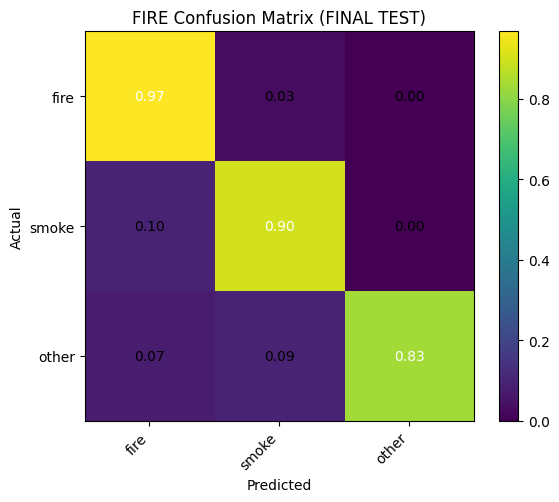

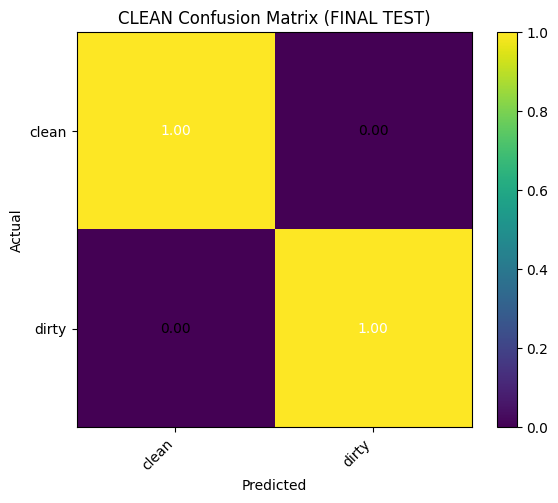

In [ ]:
# ----------------------------
# 9) FINAL TEST EVAL (ONE TIME)
# ----------------------------
best_model = tf.keras.models.load_model(FINAL_PATH)

fire_test_steps  = math.ceil(len(fire_p_test) / BATCH_SIZE)
clean_test_steps = math.ceil(len(cln_p_test) / BATCH_SIZE)

fire_test_res  = best_model.evaluate(test_fire_ds,  steps=fire_test_steps, verbose=0, return_dict=True)
clean_test_res = best_model.evaluate(test_clean_ds, steps=clean_test_steps, verbose=0, return_dict=True)

fire_acc  = float(fire_test_res.get("fire_output_accuracy", 0.0))
clean_acc = float(clean_test_res.get("clean_output_accuracy", 0.0))
score = 0.5*(fire_acc + clean_acc)

print("\n[FINAL TEST]")
print(f"fire_acc={fire_acc:.4f} | clean_acc={clean_acc:.4f} | score={score:.4f}")

# ---- classification report + confusion matrix (test)
def collect_preds(model, ds, head, n_samples):
    y_true, y_pred = [], []
    seen = 0
    for x, y, w in ds:
        out = model.predict(x, verbose=0)[head]
        pred = np.argmax(out, axis=1)
        true = y[head].numpy()

        y_pred.append(pred)
        y_true.append(true)
        seen += len(true)
        if seen >= n_samples:
            break

    yt = np.concatenate(y_true)[:n_samples]
    yp = np.concatenate(y_pred)[:n_samples]
    return yt, yp

# FIRE
yt_f, yp_f = collect_preds(best_model, test_fire_ds, "fire_output", n_samples=len(fire_p_test))
print("\n[FIRE REPORT]")
print(classification_report(yt_f, yp_f, target_names=FIRE_CLASSES, digits=4))
cm_f = confusion_matrix(yt_f, yp_f)

# CLEAN
yt_c, yp_c = collect_preds(best_model, test_clean_ds, "clean_output", n_samples=len(cln_p_test))
print("\n[CLEAN REPORT]")
print(classification_report(yt_c, yp_c, target_names=CLEAN_CLASSES, digits=4))
cm_c = confusion_matrix(yt_c, yp_c)

# plot CM (normalized)
def plot_cm(cm, names, title):
    cm = cm.astype(np.float32)
    cm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1e-9)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(names))
    plt.xticks(ticks, names, rotation=45, ha="right")
    plt.yticks(ticks, names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                     color="white" if cm[i,j] > 0.5 else "black")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

plot_cm(cm_f, FIRE_CLASSES,  "FIRE Confusion Matrix (FINAL TEST)")
plot_cm(cm_c, CLEAN_CLASSES, "CLEAN Confusion Matrix (FINAL TEST)")
